In [1]:
# ============================================================
# OGGM-VAS Historical Glacier Reconstruction
# ============================================================
#
# Purpose:
#   Reconstruct glacier evolution from 1901 to 2019 using VAS,
#   following the reconstruction concept of Marzeion et al. (2012).
#
# Current experiment:
#   RGI 6.0
#   Region 11 = Central Europe
#   Historical climate = CRU
#   Historical reconstruction = 1901-2019
#   Future projection scaffold = 2019-2100 
#
# ============================================================

In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import requests
import matplotlib.pyplot as plt

import oggm
import oggm.cfg as cfg
from oggm import utils, workflow
from oggm.core import gis, climate
from oggm.shop import gcm_climate

import oggm_vas as vascaling


In [3]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

# -------------------------
# RGI
# -------------------------

RGI_VERSION = "60"
RGI_REGION = 11

# None = whole region
# Set e.g. 20 for a small test
MAX_GLACIERS = None


# -------------------------
# Historical reconstruction
# -------------------------

MODEL_START_YEAR = 1901
HISTORICAL_END_YEAR = 2019

HISTORICAL_CLIMATE = "CRU"


# ============================================================
# FUTURE PROJECTION CONFIGURATION
# ============================================================

RUN_FUTURE = True

CMIP_VERSION = "CMIP5"
GCM = "CCSM4"
SCENARIO = "rcp85"

FUTURE_START_YEAR = 2019
FUTURE_END_YEAR = 2100

CMIP_OUTPUT_SUFFIX = f"_{GCM}_{SCENARIO}"
FUTURE_OUTPUT_SUFFIX = f"_future_{GCM}_{SCENARIO}"

# -------------------------
# Forced calibration
# -------------------------
#
# None = use the VAS reference t* table
#
FORCE_TSTAR = None
FORCE_BIAS = None


# -------------------------
# Working directory
# -------------------------

WORKDIR = Path(
    os.path.expanduser(
        f"~/oggm_work/"
        f"vas_reconstruction_rgi{RGI_VERSION}_"
        f"region{RGI_REGION}_"
        f"cru_{MODEL_START_YEAR}_{HISTORICAL_END_YEAR}"
    )
)

WORKDIR.mkdir(parents=True, exist_ok=True)



In [4]:
# ============================================================
# 3. BASIC CHECKS
# ============================================================

if RGI_VERSION != "60":
    raise NotImplementedError(
        "This script is made for rgi version 6.0, so dont use for 7.0"
    )

if not (1 <= RGI_REGION <= 19):
    raise ValueError("RGI_REGION must be between 1 and 19.")

if HISTORICAL_END_YEAR < MODEL_START_YEAR:
    raise ValueError("Historical end year must be >= model start year.")



In [5]:
# ============================================================
# 4. INITIALIZE OGGM-VAS
# ============================================================

print("\nInitializing OGGM-VAS...")

vascaling.initialize()

cfg.PATHS["working_dir"] = str(WORKDIR)

cfg.PARAMS["dl_verify"] = False
cfg.PARAMS["use_intersects"] = False
cfg.PARAMS["use_multiprocessing"] = False

cfg.PARAMS["baseline_climate"] = HISTORICAL_CLIMATE

# Use calendar years
cfg.PARAMS["hydro_month_nh"] = 1
cfg.PARAMS["hydro_month_sh"] = 1

cfg.PARAMS["run_mb_calibration"] = False
cfg.PARAMS["continue_on_error"] = True

2026-09-29 09:09:30: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-09-29 09:09:30: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-09-29 09:09:30: oggm.cfg: Multiprocessing: using all available processors (N=12)
2026-09-29 09:09:30: oggm.utils: Checking the download verification file checksum...



Initializing OGGM-VAS...


2026-09-29 09:09:33: oggm.cfg: WARNING: adding an unknown parameter `prcp_default_gradient`:`0.0004` to PARAMS.
2026-09-29 09:09:33: oggm.cfg: WARNING: adding an unknown parameter `vas_c_area_m2`:`0.1912` to PARAMS.
2026-09-29 09:09:33: oggm.cfg: WARNING: adding an unknown parameter `vas_gamma_area`:`1.375` to PARAMS.
2026-09-29 09:09:33: oggm.cfg: WARNING: adding an unknown parameter `vas_c_length_m`:`4.5214` to PARAMS.
2026-09-29 09:09:33: oggm.cfg: WARNING: adding an unknown parameter `vas_q_length`:`2.2` to PARAMS.
2026-09-29 09:09:33: oggm.cfg: WARNING: adding an unknown parameter `vas_c_icecap_area_m2`:`1.7013` to PARAMS.
2026-09-29 09:09:33: oggm.cfg: WARNING: adding an unknown parameter `vas_gamma_icecap_area`:`1.25` to PARAMS.
2026-09-29 09:09:33: oggm.cfg: WARNING: adding an unknown parameter `vas_c_icecap_length_m`:`7.1214` to PARAMS.
2026-09-29 09:09:33: oggm.cfg: WARNING: adding an unknown parameter `vas_q_icecap_length`:`2.5` to PARAMS.
2026-09-29 09:09:33: oggm.cfg: PARA

In [6]:
# ============================================================
# 5. VAS MASS-BALANCE PARAMETERS
# ============================================================
#
# These are the parameters used by the pre-calibrated
# RGI6 + CRU VAS reference calibration.
#
# Do not change these casually: local_t_star checks them
# against the VAS reference calibration table.
# ============================================================

cfg.PARAMS["temp_default_gradient"] = -0.0065

cfg.PARAMS["prcp_default_gradient"] = 0.0004

cfg.PARAMS["prcp_scaling_factor"] = 3.0

cfg.PARAMS["temp_melt"] = 0.0

cfg.PARAMS["temp_all_solid"] = 4.0


2026-09-29 09:09:33: oggm.cfg: PARAMS['prcp_scaling_factor'] changed from `2.5` to `3.0`.
2026-09-29 09:09:33: oggm.cfg: PARAMS['temp_melt'] changed from `-1.0` to `0.0`.
2026-09-29 09:09:33: oggm.cfg: PARAMS['temp_all_solid'] changed from `0.0` to `4.0`.


In [7]:
# ============================================================
# LOAD RGI 6.0 FROM NSIDC
# ============================================================

from pathlib import Path
import zipfile
import requests
import geopandas as gpd


# ------------------------------------------------------------
# RGI 6.0 region names
# ------------------------------------------------------------

RGI60_REGION_NAMES = {
    1: "Alaska",
    2: "WesternCanadaAndUSA",
    3: "ArcticCanadaNorth",
    4: "ArcticCanadaSouth",
    5: "GreenlandPeriphery",
    6: "Iceland",
    7: "Svalbard",
    8: "Scandinavia",
    9: "RussianArctic",
    10: "NorthAsia",
    11: "CentralEurope",
    12: "CaucasusMiddleEast",
    13: "CentralAsia",
    14: "SouthAsiaWest",
    15: "SouthAsiaEast",
    16: "LowLatitudes",
    17: "SouthernAndes",
    18: "NewZealand",
    19: "AntarcticSubantarctic",
}


def get_rgi60_region_file(region):

    region = int(region)

    if region not in RGI60_REGION_NAMES:
        raise ValueError(
            f"RGI 6.0 region {region} does not exist. "
            f"Choose a region between 1 and 19."
        )

    region_code = f"{region:02d}"
    region_name = RGI60_REGION_NAMES[region]

    # --------------------------------------------------------
    # Exact NSIDC RGI 6.0 file
    # --------------------------------------------------------

    filename = (
        f"nsidc0770_{region_code}.rgi60."
        f"{region_name}.zip"
    )

    url = (
        "https://daacdata.apps.nsidc.org/"
        "pub/DATASETS/nsidc0770_rgi_v6/"
        + filename
    )

    # --------------------------------------------------------
    # Local cache
    # --------------------------------------------------------

    cache_dir = (
        Path.home()
        / "OGGM"
        / "rgi60"
        / f"RGI60_{region_code}"
    )

    cache_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    zip_path = cache_dir / filename

    # --------------------------------------------------------
    # Check whether shapefile already exists
    # --------------------------------------------------------

    shapefiles = list(
        cache_dir.rglob(
            f"{region_code}*.shp"
        )
    )

    if len(shapefiles) == 1:

        print("Using cached RGI file:")
        print(shapefiles[0])

        return str(shapefiles[0])

    # --------------------------------------------------------
    # Download
    # --------------------------------------------------------

    print(
        f"\nDownloading RGI 6.0 Region "
        f"{region_code} ({region_name})..."
    )

    print(url)

    response = requests.get(
        url,
        timeout=300
    )

    response.raise_for_status()

    # Check that we received a ZIP
    if not response.content.startswith(b"PK"):
        raise RuntimeError(
            "The NSIDC server did not return a ZIP file. "
            "You may need to authenticate with NASA Earthdata."
        )

    with open(zip_path, "wb") as f:
        f.write(response.content)

    print("\nDownloaded:", zip_path)

    # --------------------------------------------------------
    # Extract
    # --------------------------------------------------------

    print("Extracting...")

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as zf:

        zf.extractall(cache_dir)

    # --------------------------------------------------------
    # Find shapefile
    # --------------------------------------------------------

    shapefiles = list(
        cache_dir.rglob(
            f"{region_code}*.shp"
        )
    )

    if len(shapefiles) != 1:
        raise RuntimeError(
            f"Expected one shapefile for "
            f"RGI region {region_code}, "
            f"but found {len(shapefiles)}."
        )

    print(
        "\nRGI shapefile:",
        shapefiles[0]
    )

    return str(shapefiles[0])


# ============================================================
# USER SELECTION
# ============================================================

if str(RGI_VERSION) not in ["6", "60"]:
    raise ValueError(
        "This section currently supports RGI 6.0."
    )

rgi_file = get_rgi60_region_file(
    RGI_REGION
)

rgidf = gpd.read_file(rgi_file)

print("\nRGI version:", RGI_VERSION)
print("RGI region:", RGI_REGION)
print("Number of glaciers in region:", len(rgidf))


# ------------------------------------------------------------
# Remove nominal glaciers
# ------------------------------------------------------------

nominal = rgidf["Status"] == 2

print(
    "Nominal glaciers found:",
    nominal.sum()
)

if nominal.any():

    print("Removing:")

    print(
        rgidf.loc[
            nominal,
            "RGIId"
        ].tolist()
    )

rgidf = rgidf.loc[
    ~nominal
].copy()

print(
    "Glaciers remaining:",
    len(rgidf)
)


# ------------------------------------------------------------
# Optional test mode
# ------------------------------------------------------------

if MAX_GLACIERS is not None:

    rgidf = rgidf.head(
        MAX_GLACIERS
    )

    print(
        "TEST MODE: using",
        len(rgidf),
        "glaciers"
    )

Using cached RGI file:
/home/JasperE/OGGM/rgi60/RGI60_11/11_rgi60_CentralEurope.shp

RGI version: 60
RGI region: 11
Number of glaciers in region: 3927
Nominal glaciers found: 2
Removing:
['RGI60-11.03235', 'RGI60-11.03237']
Glaciers remaining: 3925


In [8]:
# # ============================================================
# # 7. LOAD RGI INVENTORY
# # ============================================================

# RGI_DIR = Path(os.path.expanduser("~/OGGM/rgi60"))

# rgidf = download_rgi60_region(
#     RGI_REGION,
#     RGI_DIR
# )

# print(f"\nRGI glaciers loaded: {len(rgidf)}")



In [9]:
# ============================================================
# 8. NORMALIZE RGI ID COLUMN
# ============================================================

if "RGIId" in rgidf.columns:

    rgidf["rgi_id"] = rgidf["RGIId"]

elif "rgi_id" not in rgidf.columns:

    raise RuntimeError(
        "Could not find the RGI glacier ID column."
    )

In [10]:
# ============================================================
# 9. REMOVE NOMINAL GLACIERS
# ============================================================
#
# Status == 2 = nominal glacier.
# These caused the GeometryError in the full Central Europe run.
# ============================================================

if "Status" in rgidf.columns:

    nominal = (
        rgidf["Status"]
        .astype(str)
        .str.strip()
        == "2"
    )

else:

    nominal = np.zeros(len(rgidf), dtype=bool)


nominal_glaciers = rgidf.loc[
    nominal,
    ["rgi_id"]
].copy()

print(
    f"\nNominal glaciers excluded: "
    f"{len(nominal_glaciers)}"
)


if len(nominal_glaciers) > 0:

    nominal_glaciers.to_csv(
        WORKDIR / "nominal_glaciers_excluded.csv",
        index=False
    )


rgidf = rgidf.loc[
    ~nominal
].copy()




Nominal glaciers excluded: 0


In [11]:
# ============================================================
# 10. OPTIONAL TEST LIMIT
# ============================================================

if MAX_GLACIERS is not None:

    rgidf = rgidf.head(MAX_GLACIERS).copy()

    print(
        f"\nTEST MODE: using only the first "
        f"{MAX_GLACIERS} glaciers."
    )


print(
    f"\nGlaciers entering model: {len(rgidf)}"
)


rgidf[
    ["rgi_id"]
].to_csv(
    WORKDIR / "model_inventory.csv",
    index=False
)


Glaciers entering model: 3925


In [12]:
# ============================================================
# 11. INITIALIZE PREPROCESSED GLACIER DIRECTORIES
# ============================================================
#
# We intentionally DO NOT call gis.define_glacier_region().
#
# The current L1 preprocessed glacier directories already
# contain the required topography/grid information.
#
# This is the exact approach that worked for your current
# OGGM 1.4 environment.
# ============================================================

PREPRO_BASE_URL = (
    "https://cluster.klima.uni-bremen.de/"
    "~oggm/gdirs/oggm_v1.6/"
    "L1-L2_files/elev_bands/"
)

print("\nInitializing preprocessed glacier directories...")

gdirs = workflow.init_glacier_directories(
    rgidf,
    from_prepro_level=1,
    prepro_border=10,
    prepro_rgi_version="62",
    prepro_base_url=PREPRO_BASE_URL
)

print(
    f"Glacier directories initialized: "
    f"{len(gdirs)}"
)



Initializing preprocessed glacier directories...


2026-09-29 09:09:35: oggm.workflow: init_glacier_directories from prepro level 1 on 3925 glaciers.
2026-09-29 09:09:35: oggm.workflow: Execute entity task gdir_from_prepro on 3925 glaciers
2026-09-29 09:09:35: oggm.workflow: WARNING: you are trying to run an entity task on 3925 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.


Glacier directories initialized: 3925


In [ ]:
# ============================================================
# 12. PROCESS GLACIER MASKS
# ============================================================

print("\nProcessing glacier masks...")

workflow.execute_entity_task(
    gis.glacier_masks,
    gdirs
)

print("Glacier masks complete.")






2026-09-29 09:13:09: oggm.workflow: Execute entity task glacier_masks on 3925 glaciers
2026-09-29 09:13:09: oggm.workflow: WARNING: you are trying to run an entity task on 3925 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.
2026-09-29 09:13:09: oggm.core.gis: (RGI60-11.00001) glacier_masks
2026-09-29 09:13:09: oggm.core.gis: (RGI60-11.00001) process_dem



Processing glacier masks...


2026-09-29 09:13:09: oggm.core.gis: (RGI60-11.00002) glacier_masks
2026-09-29 09:13:09: oggm.core.gis: (RGI60-11.00002) process_dem
/home/JasperE/oggm-v140/oggm/core/gis.py:201: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  area = np.array([_tmp.area for _tmp in tmp])
/home/JasperE/oggm-v140/oggm/core/gis.py:203: ShapelyDeprecationWarning: __getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  tmp = tmp[_tokeep]
2026-09-29 09:13:10: oggm.core.gis: (RGI60-11.00003) glacier_masks
2026-09-29 09:13:10: oggm.core.gis: (RGI60-11.00003) process_dem
2026-09-29 09:13:10: oggm.core.gis: (RGI60-11.00004) glacier_masks
2026-09-29 09:13:10: oggm.core.gis: (RGI60-11.00004) process_dem
2026-09-29 09:13:11: oggm.core.gis: (RGI60-11.000

In [14]:
# ============================================================
# 13. PROCESS HISTORICAL CRU CLIMATE
# ============================================================
#
# The climate record must cover the entire reconstruction period.
# ============================================================

print(
    f"\nProcessing CRU climate "
    f"{MODEL_START_YEAR}-{HISTORICAL_END_YEAR}..."
)

workflow.execute_entity_task(
    climate.process_climate_data,
    gdirs,
    y0=MODEL_START_YEAR,
    y1=HISTORICAL_END_YEAR
)

print("Historical climate processing complete.")

2026-09-29 09:46:31: oggm.core.climate: (RGI60-11.00071) process_climate_data
2026-09-29 09:46:31: oggm.shop.cru: (RGI60-11.00071) process_cru_data
2026-09-29 09:46:31: oggm.core.climate: (RGI60-11.00072) process_climate_data
2026-09-29 09:46:31: oggm.shop.cru: (RGI60-11.00072) process_cru_data
2026-09-29 09:46:32: oggm.core.climate: (RGI60-11.00073) process_climate_data
2026-09-29 09:46:32: oggm.shop.cru: (RGI60-11.00073) process_cru_data
2026-09-29 09:46:32: oggm.core.climate: (RGI60-11.00074) process_climate_data
2026-09-29 09:46:32: oggm.shop.cru: (RGI60-11.00074) process_cru_data
2026-09-29 09:46:32: oggm.core.climate: (RGI60-11.00075) process_climate_data
2026-09-29 09:46:32: oggm.shop.cru: (RGI60-11.00075) process_cru_data
2026-09-29 09:46:33: oggm.core.climate: (RGI60-11.00076) process_climate_data
2026-09-29 09:46:33: oggm.shop.cru: (RGI60-11.00076) process_cru_data
2026-09-29 09:46:33: oggm.core.climate: (RGI60-11.00077) process_climate_data
2026-09-29 09:46:33: oggm.shop.cru

Historical climate processing complete.


In [15]:
# ============================================================
# 14. VAS CALIBRATION
# ============================================================
#
# This is still the same VAS calibration as before.
#
# The important difference is what happens AFTER calibration:
#
#   OLD:
#       RGI date -> 2019
#
#   NEW:
#       1901 -> RGI date -> 2019
#
# The historical VAS task finds the 1901 starting area that
# evolves to the observed RGI area.
# ============================================================

print("\nCalibrating VAS t*, bias and mu*...")

if FORCE_TSTAR is None or FORCE_BIAS is None:

    workflow.execute_entity_task(
        vascaling.local_t_star,
        gdirs,
        continue_on_error=True
    )

else:

    workflow.execute_entity_task(
        vascaling.local_t_star,
        gdirs,
        tstar=FORCE_TSTAR,
        bias=FORCE_BIAS,
        continue_on_error=True
    )



2026-09-29 10:13:08: oggm.workflow: Execute entity task local_t_star on 3925 glaciers
2026-09-29 10:13:08: oggm.workflow: WARNING: you are trying to run an entity task on 3925 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00001) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00002) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00003) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00004) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00005) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00006) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00007) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00008) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00009) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00010) local_t_star
2026-09-29 10:13:08: oggm_vas.core: (RGI60-11.00011) local_t_star
202


Calibrating VAS t*, bias and mu*...


2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00013) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00014) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00015) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00016) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00017) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00018) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00019) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00020) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00021) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00022) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00023) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00024) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00025) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00026) local_t_star
2026-09-29 10:13:09: oggm_vas.core: (RGI60-11.00027) local_t_star
2026-09-29

In [16]:
# ============================================================
# 15. IDENTIFY SUCCESSFULLY CALIBRATED GLACIERS
# ============================================================

valid_gdirs = []
failed_calibrations = []

calibration_records = []


for gdir in gdirs:

    try:

        cal = gdir.read_json(
            "vascaling_mustar"
        )

        tstar = cal.get("t_star", np.nan)
        bias = cal.get("bias", np.nan)
        mustar = cal.get("mu_star", np.nan)

        record = {
            "rgi_id": gdir.rgi_id,
            "t_star": tstar,
            "bias": bias,
            "mu_star": mustar
        }

        calibration_records.append(record)

        if (
            np.isfinite(tstar)
            and np.isfinite(bias)
            and np.isfinite(mustar)
        ):

            valid_gdirs.append(gdir)

        else:

            failed_calibrations.append(
                gdir.rgi_id
            )

    except Exception:

        failed_calibrations.append(
            gdir.rgi_id
        )


print(
    f"\nCalibration results:"
    f"\n  Valid: {len(valid_gdirs)}"
    f"\n  Failed: {len(failed_calibrations)}"
)


pd.DataFrame(
    calibration_records
).to_csv(
    WORKDIR / "vas_calibration.csv",
    index=False
)


pd.DataFrame(
    {
        "rgi_id": failed_calibrations
    }
).to_csv(
    WORKDIR / "failed_calibrations.csv",
    index=False
)


# From this point onward only use successfully calibrated glaciers.
gdirs = valid_gdirs


if len(gdirs) == 0:

    raise RuntimeError(
        "No glaciers have a valid VAS calibration."
    )


Calibration results:
  Valid: 3885
  Failed: 40


In [ ]:
# ============================================================
# 16. HISTORICAL VAS RECONSTRUCTION: 1901-2019
# ============================================================

print(
    f"\nRunning historical VAS reconstruction "
    f"{MODEL_START_YEAR}-{HISTORICAL_END_YEAR}..."
)


hist_models = workflow.execute_entity_task(
    vascaling.run_historic_from_climate_data,
    gdirs,
    ys=MODEL_START_YEAR,
    ye=HISTORICAL_END_YEAR,
    climate_filename="climate_historical",
    output_filesuffix="_hist1901_2019",
    continue_on_error=True
)


print("Historical VAS reconstruction complete.")


2026-09-29 10:14:16: oggm.workflow: Execute entity task run_historic_from_climate_data on 3885 glaciers
2026-09-29 10:14:16: oggm.workflow: WARNING: you are trying to run an entity task on 3885 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.
2026-09-29 10:14:16: oggm_vas.core: (RGI60-11.00001) run_historic_from_climate_data_hist1901_2019
2026-09-29 10:14:16: oggm_vas.core: (RGI60-11.00001) find_start_area



Running historical VAS reconstruction 1901-2019...


2026-09-29 10:14:17: oggm_vas.core: (RGI60-11.00002) run_historic_from_climate_data_hist1901_2019
2026-09-29 10:14:17: oggm_vas.core: (RGI60-11.00002) find_start_area
2026-09-29 10:14:18: oggm_vas.core: (RGI60-11.00003) run_historic_from_climate_data_hist1901_2019
2026-09-29 10:14:18: oggm_vas.core: (RGI60-11.00003) find_start_area
2026-09-29 10:14:18: oggm_vas.core: (RGI60-11.00004) run_historic_from_climate_data_hist1901_2019
2026-09-29 10:14:18: oggm_vas.core: (RGI60-11.00004) find_start_area
2026-09-29 10:14:19: oggm_vas.core: (RGI60-11.00005) run_historic_from_climate_data_hist1901_2019
2026-09-29 10:14:19: oggm_vas.core: (RGI60-11.00005) find_start_area
2026-09-29 10:14:20: oggm_vas.core: (RGI60-11.00006) run_historic_from_climate_data_hist1901_2019
2026-09-29 10:14:20: oggm_vas.core: (RGI60-11.00006) find_start_area
2026-09-29 10:14:20: oggm_vas.core: (RGI60-11.00007) run_historic_from_climate_data_hist1901_2019
2026-09-29 10:14:20: oggm_vas.core: (RGI60-11.00007) find_start_are

In [ ]:
# ============================================================
# 17. IDENTIFY SUCCESSFUL HISTORICAL RUNS
# ============================================================

successful_hist_gdirs = []
failed_historical_runs = []
historical_initial_states = []


for gdir, model in zip(gdirs, hist_models):

    if model is None:

        failed_historical_runs.append(
            gdir.rgi_id
        )

        continue


    successful_hist_gdirs.append(gdir)


    # Store the reconstructed 1901 initial state.
    historical_initial_states.append(
        {
            "rgi_id": gdir.rgi_id,
            "model_start_year": model.year_0,
            "start_area_km2": model.area_m2_0 * 1e-6,
            "start_volume_km3": model.volume_m3_0 * 1e-9,
            "start_length_km": model.length_m_0 * 1e-3,
            "rgi_area_km2": gdir.rgi_area_m2 * 1e-6,
            "rgi_date": gdir.rgi_date,
        }
    )


print(
    f"\nHistorical run results:"
    f"\n  Successful: {len(successful_hist_gdirs)}"
    f"\n  Failed: {len(failed_historical_runs)}"
)


pd.DataFrame(
    {
        "rgi_id": failed_historical_runs
    }
).to_csv(
    WORKDIR / "failed_historical_runs.csv",
    index=False
)


pd.DataFrame(
    historical_initial_states
).to_csv(
    WORKDIR / "historical_initial_states_1901.csv",
    index=False
)


# Use only glaciers with a completed historical run.
gdirs = successful_hist_gdirs


if len(gdirs) == 0:

    raise RuntimeError(
        "No successful historical VAS runs."
    )

In [19]:
# ============================================================
# 18. EXTRACT YEARLY GLACIER RESULTS
# ============================================================

print("\nReading yearly VAS diagnostics...")

glacier_results = []


for i, gdir in enumerate(gdirs, start=1):

    fp = gdir.get_filepath(
        "model_diagnostics",
        filesuffix="_hist1901_2019"
    )

    try:

        with xr.open_dataset(fp) as ds:

            df = pd.DataFrame(
                {
                    "year": np.asarray(
                        ds["time"].values,
                        dtype=float
                    ),

                    "volume_km3": (
                        ds["volume_m3"].values
                        * 1e-9
                    ),

                    "area_km2": (
                        ds["area_m2"].values
                        * 1e-6
                    ),

                    "length_km": (
                        ds["length_m"].values
                        * 1e-3
                    ),

                    "specific_mb_mmwe": (
                        ds["spec_mb"].values
                    ),

                    "terminus_elevation_m": (
                        ds["min_hgt"].values
                    ),

                    "tau_area_years": (
                        ds["tau_a"].values
                    ),

                    "tau_length_years": (
                        ds["tau_l"].values
                    ),
                }
            )

        df["year"] = df["year"].astype(int)

        df["rgi_id"] = gdir.rgi_id

        glacier_results.append(df)


    except Exception as exc:

        print(
            f"Could not read {gdir.rgi_id}: {exc}"
        )


    if i % 100 == 0:

        print(
            f"  Read {i}/{len(gdirs)} glaciers..."
        )


if not glacier_results:

    raise RuntimeError(
        "No glacier model diagnostics could be read."
    )


glacier_results = pd.concat(
    glacier_results,
    ignore_index=True
)


glacier_results = glacier_results.sort_values(
    ["rgi_id", "year"]
)


# Save glacier-level data.
glacier_results.to_csv(
    WORKDIR / "glacier_results_hist1901_2019.csv",
    index=False
)


print(
    "\nGlacier-level results saved."
)



  Read 2100/3885 glaciers...
  Read 2200/3885 glaciers...
  Read 2300/3885 glaciers...
  Read 2400/3885 glaciers...
  Read 2500/3885 glaciers...
  Read 2600/3885 glaciers...
  Read 2700/3885 glaciers...
  Read 2800/3885 glaciers...
  Read 2900/3885 glaciers...
  Read 3000/3885 glaciers...
  Read 3100/3885 glaciers...
  Read 3200/3885 glaciers...
  Read 3300/3885 glaciers...
  Read 3400/3885 glaciers...
  Read 3500/3885 glaciers...
  Read 3600/3885 glaciers...
  Read 3700/3885 glaciers...
  Read 3800/3885 glaciers...

Glacier-level results saved.


In [20]:
# ============================================================
# 19. REGIONAL AGGREGATION
# ============================================================
#
# Volume and area are physically meaningful regional sums.
#
# Length is simply the sum of individual glacier lengths.
# It should therefore be interpreted as total glacier length,
# NOT as the length of one hypothetical Central European glacier.
# ============================================================

print("\nAggregating region ...")

regional_df = (
    glacier_results
    .groupby(
        "year",
        as_index=False
    )
    .agg(
        {
            "volume_km3": "sum",
            "area_km2": "sum",
            "length_km": "sum"
        }
    )
)


regional_df = regional_df.sort_values(
    "year"
).reset_index(drop=True)

print("\nAggregating region succeeded")


Aggregating region ...

Aggregating region succeeded


In [21]:
# ============================================================
# 20. CALCULATE CHANGE RELATIVE TO 1901
# ============================================================

initial_volume = regional_df.loc[
    regional_df["year"] == MODEL_START_YEAR,
    "volume_km3"
].iloc[0]


initial_area = regional_df.loc[
    regional_df["year"] == MODEL_START_YEAR,
    "area_km2"
].iloc[0]


initial_length = regional_df.loc[
    regional_df["year"] == MODEL_START_YEAR,
    "length_km"
].iloc[0]


regional_df["volume_change_km3"] = (
    regional_df["volume_km3"]
    - initial_volume
)


regional_df["area_change_km2"] = (
    regional_df["area_km2"]
    - initial_area
)


regional_df["length_change_km"] = (
    regional_df["length_km"]
    - initial_length
)


# Positive mass loss.
regional_df["volume_loss_km3"] = (
    initial_volume
    - regional_df["volume_km3"]
)

In [22]:
# ============================================================
# 21. SEA-LEVEL EQUIVALENT
# ============================================================
#
# Conversion:
#
#   SLE = volume * rho_ice/rho_water / ocean_area
#
# We use:
#
#   ice density   = 900 kg m-3
#   water density = 1000 kg m-3
#   ocean area    = 3.625e8 km2
#
# This gives the approximate global mean sea-level equivalent
# associated with the modeled regional glacier volume change.
#
# Positive values = sea-level rise caused by glacier loss.
# ============================================================

RHO_ICE = 900.0
RHO_WATER = 1000.0
OCEAN_AREA_KM2 = 3.625e8


regional_df["mass_loss_Gt"] = (
    regional_df["volume_loss_km3"]
    * RHO_ICE
    * 1e-3
)


regional_df["sea_level_change_mm"] = (
    regional_df["volume_loss_km3"]
    * (RHO_ICE / RHO_WATER)
    / OCEAN_AREA_KM2
    * 1e6
)


# ============================================================
# 22. ANNUAL SEA-LEVEL CONTRIBUTION
# ============================================================

regional_df["annual_mass_change_Gt_yr"] = (
    regional_df["mass_loss_Gt"].diff()
)


regional_df["annual_sle_mm_yr"] = (
    regional_df["sea_level_change_mm"].diff()
)



In [23]:
# ============================================================
# 23. SAVE REGIONAL RESULTS
# ============================================================

regional_df.to_csv(
    WORKDIR / "regional_results_hist1901_2019.csv",
    index=False
)


print(
    "\nRegional results saved:"
)


print(
    WORKDIR / "regional_results_hist1901_2019.csv"
)



Regional results saved:
/home/JasperE/oggm_work/vas_reconstruction_rgi60_region11_cru_1901_2019/regional_results_hist1901_2019.csv


In [24]:
# ============================================================
# 24. PRINT BASIC RESULTS
# ============================================================

row_1901 = regional_df.loc[
    regional_df["year"] == MODEL_START_YEAR
].iloc[0]


row_2019 = regional_df.loc[
    regional_df["year"] == HISTORICAL_END_YEAR
].iloc[0]


print("\n========================================")
print("HISTORICAL RECONSTRUCTION SUMMARY")
print("========================================")

print(
    f"Region: RGI60-{RGI_REGION:02d}"
)

print(
    f"Modeled glaciers: {len(gdirs)}"
)

print(
    f"Period: {MODEL_START_YEAR}-{HISTORICAL_END_YEAR}"
)

print(
    f"\nReconstructed regional volume in "
    f"{MODEL_START_YEAR}: "
    f"{row_1901['volume_km3']:.3f} km3"
)

print(
    f"Regional volume in "
    f"{HISTORICAL_END_YEAR}: "
    f"{row_2019['volume_km3']:.3f} km3"
)

print(
    f"\nVolume lost: "
    f"{row_2019['volume_loss_km3']:.3f} km3"
)

print(
    f"Mass lost: "
    f"{row_2019['mass_loss_Gt']:.3f} Gt"
)

print(
    f"Sea-level equivalent: "
    f"{row_2019['sea_level_change_mm']:.5f} mm"
)




HISTORICAL RECONSTRUCTION SUMMARY
Region: RGI60-11
Modeled glaciers: 3885
Period: 1901-2019

Reconstructed regional volume in 1901: 146.643 km3
Regional volume in 2019: 93.009 km3

Volume lost: 53.635 km3
Mass lost: 48.271 Gt
Sea-level equivalent: 0.13316 mm


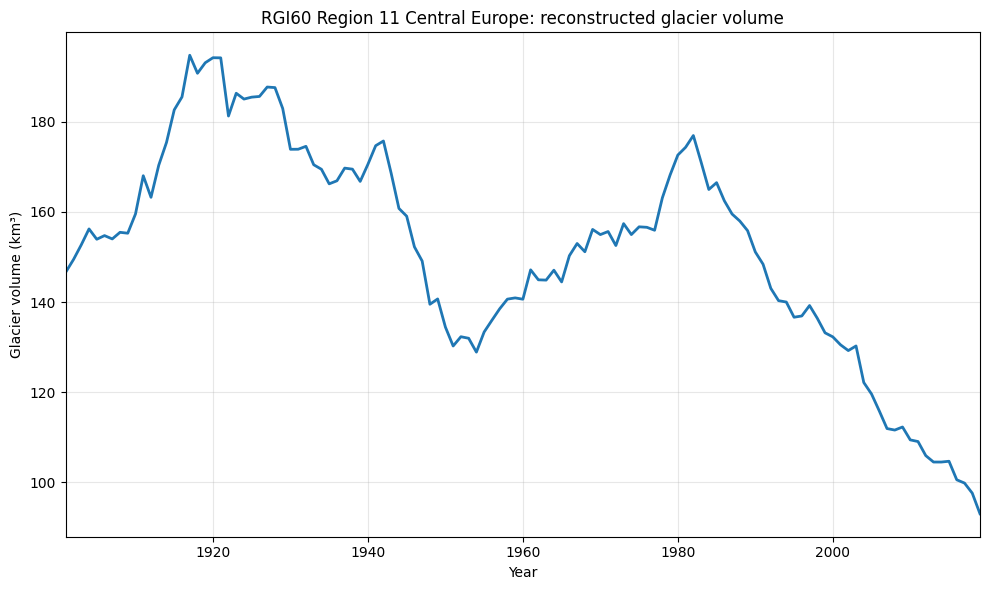

In [25]:
# ============================================================
# 25. PLOT: REGIONAL GLACIER VOLUME
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    regional_df["year"],
    regional_df["volume_km3"],
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Glacier volume (km³)")
plt.title(
    f"RGI60 Region {RGI_REGION:02d} "
    "Central Europe: reconstructed glacier volume"
)

plt.xlim(
    MODEL_START_YEAR,
    HISTORICAL_END_YEAR
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    WORKDIR / "central_europe_volume_1901_2019.png",
    dpi=300
)

plt.show()



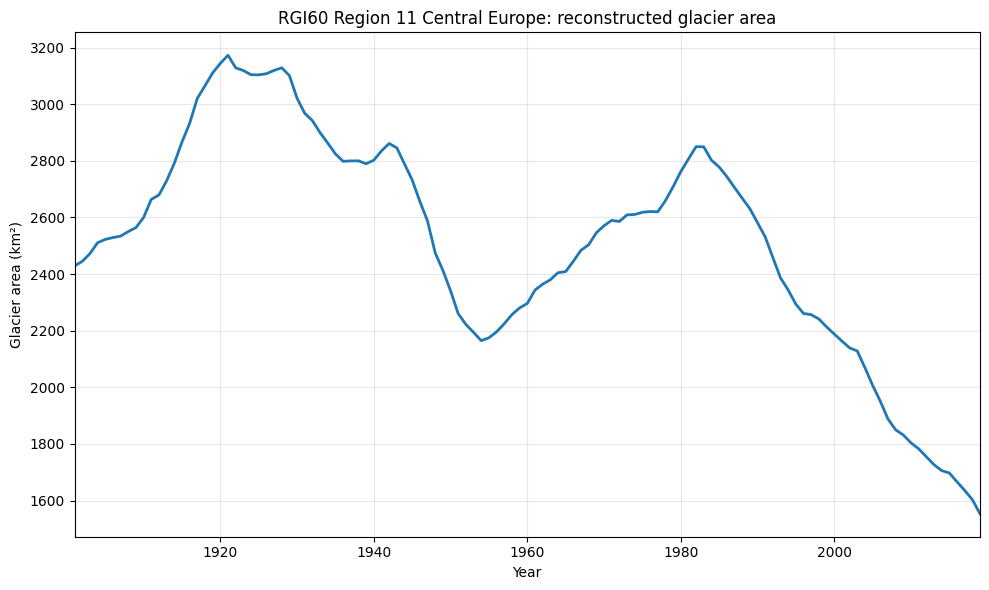

In [26]:
# ============================================================
# 26. PLOT: REGIONAL GLACIER AREA
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    regional_df["year"],
    regional_df["area_km2"],
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Glacier area (km²)")
plt.title(
    f"RGI60 Region {RGI_REGION:02d} "
    "Central Europe: reconstructed glacier area"
)

plt.xlim(
    MODEL_START_YEAR,
    HISTORICAL_END_YEAR
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    WORKDIR / "central_europe_area_1901_2019.png",
    dpi=300
)

plt.show()


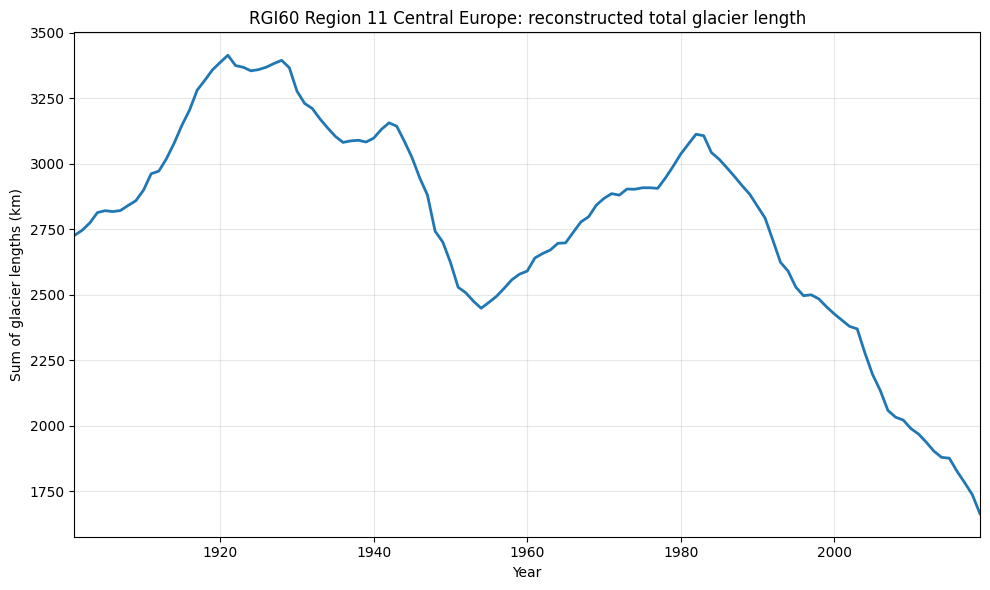

In [27]:
# ============================================================
# 27. PLOT: TOTAL GLACIER LENGTH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    regional_df["year"],
    regional_df["length_km"],
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Sum of glacier lengths (km)")
plt.title(
    f"RGI60 Region {RGI_REGION:02d} "
    "Central Europe: reconstructed total glacier length"
)

plt.xlim(
    MODEL_START_YEAR,
    HISTORICAL_END_YEAR
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    WORKDIR / "central_europe_length_1901_2019.png",
    dpi=300
)

plt.show()



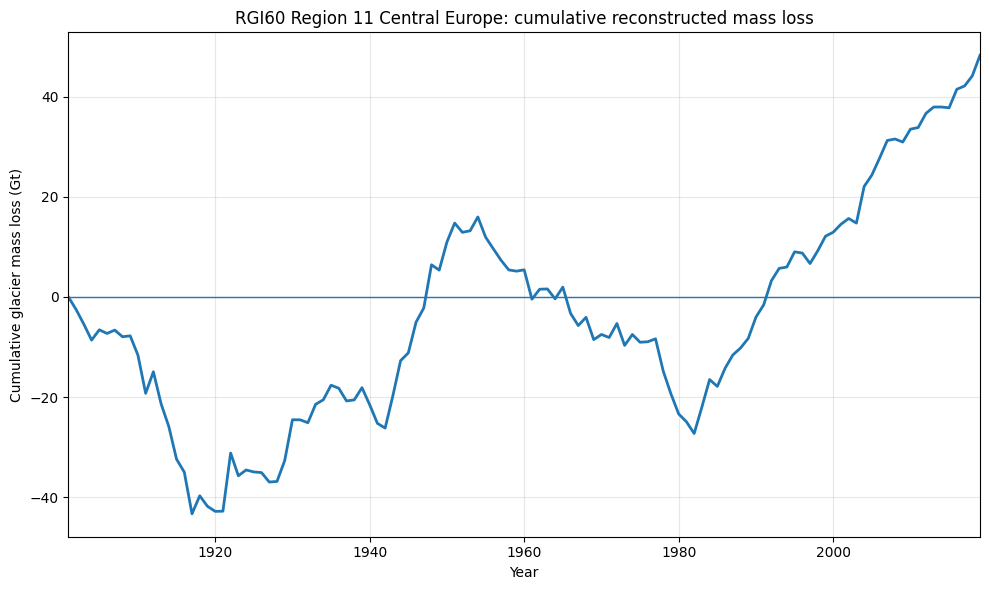

In [28]:
# ============================================================
# 28. PLOT: CUMULATIVE GLACIER MASS LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    regional_df["year"],
    regional_df["mass_loss_Gt"],
    linewidth=2
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Year")
plt.ylabel("Cumulative glacier mass loss (Gt)")
plt.title(
    f"RGI60 Region {RGI_REGION:02d} "
    "Central Europe: cumulative reconstructed mass loss"
)

plt.xlim(
    MODEL_START_YEAR,
    HISTORICAL_END_YEAR
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    WORKDIR / "central_europe_mass_loss_1901_2019.png",
    dpi=300
)

plt.show()



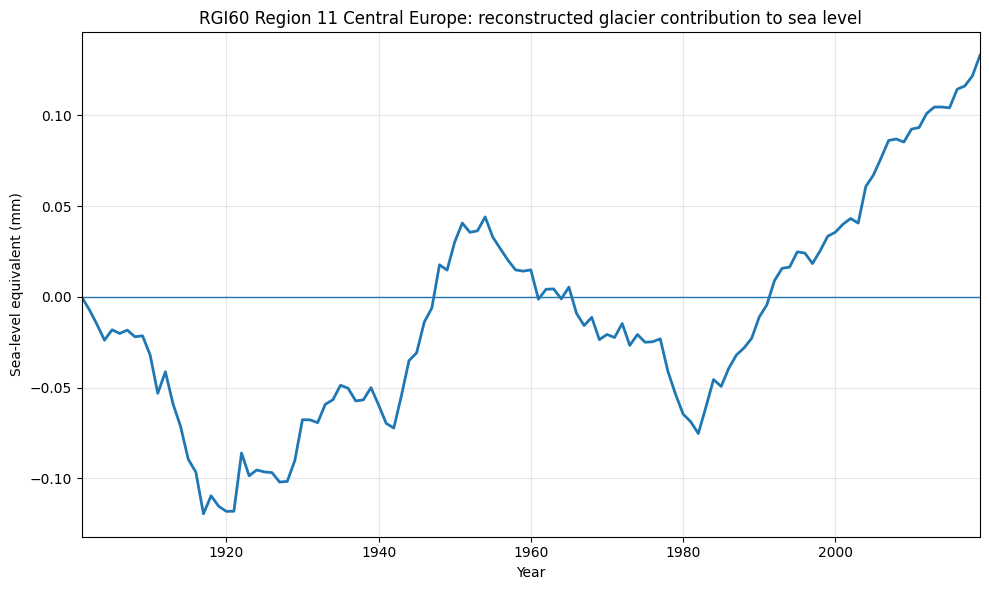

In [29]:

# ============================================================
# 29. PLOT: SEA-LEVEL EQUIVALENT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    regional_df["year"],
    regional_df["sea_level_change_mm"],
    linewidth=2
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Year")
plt.ylabel("Sea-level equivalent (mm)")
plt.title(
    f"RGI60 Region {RGI_REGION:02d} "
    "Central Europe: reconstructed glacier contribution "
    "to sea level"
)

plt.xlim(
    MODEL_START_YEAR,
    HISTORICAL_END_YEAR
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    WORKDIR / "central_europe_sle_1901_2019.png",
    dpi=300
)

plt.show()



In [30]:
# ============================================================
# 30. DOWNLOAD CMIP5 CLIMATE DATA
# ============================================================

if RUN_FUTURE:

    print("\nPreparing CMIP5 climate data...")
    print(f"GCM: {GCM}")
    print(f"Scenario: {SCENARIO}")

    # --------------------------------------------------------
    # OGGM CMIP5 files on the Bremen server
    # --------------------------------------------------------

    cmip_temp_url = (
        "https://cluster.klima.uni-bremen.de/"
        "~oggm/cmip5-ng/tas/"
        f"tas_mon_{GCM}_{SCENARIO}_r1i1p1_g025.nc"
    )

    cmip_precip_url = (
        "https://cluster.klima.uni-bremen.de/"
        "~oggm/cmip5-ng/pr/"
        f"pr_mon_{GCM}_{SCENARIO}_r1i1p1_g025.nc"
    )

    print("\nTemperature file:")
    print(cmip_temp_url)

    print("\nPrecipitation file:")
    print(cmip_precip_url)


    # --------------------------------------------------------
    # Download using OGGM's downloader
    # --------------------------------------------------------

    cmip_temp_file = utils.file_downloader(
        cmip_temp_url
    )

    cmip_precip_file = utils.file_downloader(
        cmip_precip_url
    )


    print("\nCMIP temperature file:")
    print(cmip_temp_file)

    print("\nCMIP precipitation file:")
    print(cmip_precip_file)



Preparing CMIP5 climate data...
GCM: CCSM4
Scenario: rcp85

Temperature file:
https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_rcp85_r1i1p1_g025.nc

Precipitation file:
https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_rcp85_r1i1p1_g025.nc

CMIP temperature file:
/home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_rcp85_r1i1p1_g025.nc

CMIP precipitation file:
/home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_rcp85_r1i1p1_g025.nc


In [31]:
# ============================================================
# 30. FUTURE PROJECTION CONFIGURATION
# ============================================================

RUN_FUTURE = True

GCM = "CCSM4"

FUTURE_START_YEAR = 2019
FUTURE_END_YEAR = 2100

# All scenarios we want to calculate
PROJECTIONS = {
    "rcp26": {
        "label": "RCP2.6",
        "linestyle": "--"
    },

    "rcp45": {
        "label": "RCP4.5",
        "linestyle": "-."
    },

    "rcp85": {
        "label": "RCP8.5",
        "linestyle": "-"
    }
}



In [32]:
# ============================================================
# 31. PREPARE CMIP5 FILES
# ============================================================

if RUN_FUTURE:

    print("\nPreparing CMIP5 projection data...")

    cmip_files = {}


    for scenario in PROJECTIONS:

        print(
            f"\nPreparing {GCM} {scenario}..."
        )

        # ----------------------------------------------------
        # Exact OGGM CMIP5 file names
        # ----------------------------------------------------

        temp_url = (
            "https://cluster.klima.uni-bremen.de/"
            "~oggm/cmip5-ng/tas/"
            f"tas_mon_{GCM}_{scenario}_r1i1p1_g025.nc"
        )

        precip_url = (
            "https://cluster.klima.uni-bremen.de/"
            "~oggm/cmip5-ng/pr/"
            f"pr_mon_{GCM}_{scenario}_r1i1p1_g025.nc"
        )


        # ----------------------------------------------------
        # Download / use cache
        # ----------------------------------------------------

        temp_file = utils.file_downloader(
            temp_url
        )

        precip_file = utils.file_downloader(
            precip_url
        )


        cmip_files[scenario] = {
            "temp": temp_file,
            "precip": precip_file
        }


        print(
            "Temperature:",
            temp_file
        )

        print(
            "Precipitation:",
            precip_file
        )



2026-09-29 11:02:18: oggm.utils: Downloading https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_rcp26_r1i1p1_g025.nc to /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_rcp26_r1i1p1_g025.nc...



Preparing CMIP5 projection data...

Preparing CCSM4 rcp26...


2026-09-29 11:02:23: oggm.utils: Downloading https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_rcp26_r1i1p1_g025.nc to /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_rcp26_r1i1p1_g025.nc...
2026-09-29 11:02:28: oggm.utils: Downloading https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_rcp45_r1i1p1_g025.nc to /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_rcp45_r1i1p1_g025.nc...


Temperature: /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_rcp26_r1i1p1_g025.nc
Precipitation: /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_rcp26_r1i1p1_g025.nc

Preparing CCSM4 rcp45...


2026-09-29 11:02:33: oggm.utils: Downloading https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_rcp45_r1i1p1_g025.nc to /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_rcp45_r1i1p1_g025.nc...


Temperature: /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_rcp45_r1i1p1_g025.nc
Precipitation: /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_rcp45_r1i1p1_g025.nc

Preparing CCSM4 rcp85...
Temperature: /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/tas/tas_mon_CCSM4_rcp85_r1i1p1_g025.nc
Precipitation: /home/JasperE/OGGM/download_cache/cluster.klima.uni-bremen.de/~oggm/cmip5-ng/pr/pr_mon_CCSM4_rcp85_r1i1p1_g025.nc


In [33]:
# ============================================================
# 32. PROCESS CMIP5 FOR EVERY GLACIER AND EVERY SCENARIO
# ============================================================

if RUN_FUTURE:

    cfg.PARAMS["continue_on_error"] = True

    cmip_gdirs_by_scenario = {}


    for scenario in PROJECTIONS:

        print(
            f"\n========================================"
        )

        print(
            f"Processing {GCM} {scenario}"
        )

        print(
            f"========================================"
        )


        filesuffix = (
            f"_{GCM}_{scenario}"
        )


        # ----------------------------------------------------
        # Find glaciers which do NOT yet have the CMIP file
        # ----------------------------------------------------

        missing_gdirs = []


        for gdir in gdirs:

            cmip_file = gdir.get_filepath(
                "gcm_data",
                filesuffix=filesuffix
            )

            if not os.path.exists(cmip_file):

                missing_gdirs.append(gdir)


        print(
            f"Glaciers already processed: "
            f"{len(gdirs) - len(missing_gdirs)}"
        )

        print(
            f"Glaciers still to process: "
            f"{len(missing_gdirs)}"
        )


        # ----------------------------------------------------
        # Process only missing glacier files
        # ----------------------------------------------------

        if missing_gdirs:

            workflow.execute_entity_task(
                gcm_climate.process_cmip_data,
                missing_gdirs,
                filesuffix=filesuffix,
                fpath_temp=cmip_files[scenario]["temp"],
                fpath_precip=cmip_files[scenario]["precip"],
                year_range=("1961", "1990"),
                scale_stddev=True
            )


        # ----------------------------------------------------
        # Check output files
        # ----------------------------------------------------

        scenario_gdirs = []
        failed = []


        for gdir in gdirs:

            cmip_file = gdir.get_filepath(
                "gcm_data",
                filesuffix=filesuffix
            )


            if os.path.exists(cmip_file):

                scenario_gdirs.append(gdir)

            else:

                failed.append(
                    gdir.rgi_id
                )


        print(
            f"\n{scenario} CMIP results:"
        )

        print(
            "  Successful:",
            len(scenario_gdirs)
        )

        print(
            "  Failed:",
            len(failed)
        )


        pd.DataFrame(
            {
                "rgi_id": failed
            }
        ).to_csv(
            WORKDIR /
            f"failed_cmip_{GCM}_{scenario}.csv",
            index=False
        )


        cmip_gdirs_by_scenario[scenario] = (
            scenario_gdirs
        )



2026-09-29 11:02:38: oggm.workflow: Execute entity task process_cmip_data on 3885 glaciers
2026-09-29 11:02:38: oggm.workflow: WARNING: you are trying to run an entity task on 3885 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.
2026-09-29 11:02:38: oggm.shop.gcm_climate: (RGI60-11.00001) process_cmip_data_CCSM4_rcp26



Processing CCSM4 rcp26
Glaciers already processed: 0
Glaciers still to process: 3885


2026-09-29 11:02:38: oggm.shop.gcm_climate: (RGI60-11.00001) process_gcm_data_CCSM4_rcp26
2026-09-29 11:02:38: oggm.shop.gcm_climate: (RGI60-11.00002) process_cmip_data_CCSM4_rcp26
2026-09-29 11:02:39: oggm.shop.gcm_climate: (RGI60-11.00002) process_gcm_data_CCSM4_rcp26
2026-09-29 11:02:39: oggm.shop.gcm_climate: (RGI60-11.00003) process_cmip_data_CCSM4_rcp26
2026-09-29 11:02:39: oggm.shop.gcm_climate: (RGI60-11.00003) process_gcm_data_CCSM4_rcp26
2026-09-29 11:02:40: oggm.shop.gcm_climate: (RGI60-11.00004) process_cmip_data_CCSM4_rcp26
2026-09-29 11:02:40: oggm.shop.gcm_climate: (RGI60-11.00004) process_gcm_data_CCSM4_rcp26
2026-09-29 11:02:40: oggm.shop.gcm_climate: (RGI60-11.00005) process_cmip_data_CCSM4_rcp26
2026-09-29 11:02:41: oggm.shop.gcm_climate: (RGI60-11.00005) process_gcm_data_CCSM4_rcp26
2026-09-29 11:02:41: oggm.shop.gcm_climate: (RGI60-11.00006) process_cmip_data_CCSM4_rcp26
2026-09-29 11:02:41: oggm.shop.gcm_climate: (RGI60-11.00006) process_gcm_data_CCSM4_rcp26
2026-


rcp26 CMIP results:
  Successful: 3885
  Failed: 0

Processing CCSM4 rcp45
Glaciers already processed: 0
Glaciers still to process: 3885


2026-09-29 11:42:49: oggm.shop.gcm_climate: (RGI60-11.00001) process_gcm_data_CCSM4_rcp45
2026-09-29 11:42:49: oggm.shop.gcm_climate: (RGI60-11.00002) process_cmip_data_CCSM4_rcp45
2026-09-29 11:42:49: oggm.shop.gcm_climate: (RGI60-11.00002) process_gcm_data_CCSM4_rcp45
2026-09-29 11:42:50: oggm.shop.gcm_climate: (RGI60-11.00003) process_cmip_data_CCSM4_rcp45
2026-09-29 11:42:50: oggm.shop.gcm_climate: (RGI60-11.00003) process_gcm_data_CCSM4_rcp45
2026-09-29 11:42:50: oggm.shop.gcm_climate: (RGI60-11.00004) process_cmip_data_CCSM4_rcp45
2026-09-29 11:42:51: oggm.shop.gcm_climate: (RGI60-11.00004) process_gcm_data_CCSM4_rcp45
2026-09-29 11:42:51: oggm.shop.gcm_climate: (RGI60-11.00005) process_cmip_data_CCSM4_rcp45
2026-09-29 11:42:52: oggm.shop.gcm_climate: (RGI60-11.00005) process_gcm_data_CCSM4_rcp45
2026-09-29 11:42:52: oggm.shop.gcm_climate: (RGI60-11.00006) process_cmip_data_CCSM4_rcp45
2026-09-29 11:42:52: oggm.shop.gcm_climate: (RGI60-11.00006) process_gcm_data_CCSM4_rcp45
2026-


rcp45 CMIP results:
  Successful: 3885
  Failed: 0

Processing CCSM4 rcp85
Glaciers already processed: 0
Glaciers still to process: 3885


2026-09-29 12:42:03: oggm.shop.gcm_climate: (RGI60-11.00001) process_gcm_data_CCSM4_rcp85
2026-09-29 12:42:04: oggm.shop.gcm_climate: (RGI60-11.00002) process_cmip_data_CCSM4_rcp85
2026-09-29 12:42:04: oggm.shop.gcm_climate: (RGI60-11.00002) process_gcm_data_CCSM4_rcp85
2026-09-29 12:42:04: oggm.shop.gcm_climate: (RGI60-11.00003) process_cmip_data_CCSM4_rcp85
2026-09-29 12:42:05: oggm.shop.gcm_climate: (RGI60-11.00003) process_gcm_data_CCSM4_rcp85
2026-09-29 12:42:05: oggm.shop.gcm_climate: (RGI60-11.00004) process_cmip_data_CCSM4_rcp85
2026-09-29 12:42:05: oggm.shop.gcm_climate: (RGI60-11.00004) process_gcm_data_CCSM4_rcp85
2026-09-29 12:42:05: oggm.shop.gcm_climate: (RGI60-11.00005) process_cmip_data_CCSM4_rcp85
2026-09-29 12:42:06: oggm.shop.gcm_climate: (RGI60-11.00005) process_gcm_data_CCSM4_rcp85
2026-09-29 12:42:06: oggm.shop.gcm_climate: (RGI60-11.00006) process_cmip_data_CCSM4_rcp85
2026-09-29 12:42:06: oggm.shop.gcm_climate: (RGI60-11.00006) process_gcm_data_CCSM4_rcp85
2026-


rcp85 CMIP results:
  Successful: 3885
  Failed: 0


In [34]:
# ============================================================
# 33. RUN FUTURE VAS PROJECTIONS
# ============================================================

if RUN_FUTURE:

    future_regional_by_scenario = {}
    future_glacier_by_scenario = {}


    for scenario in PROJECTIONS:

        print(
            f"\n========================================"
        )

        print(
            f"VAS projection: {GCM} {scenario}"
        )

        print(
            f"========================================"
        )


        scenario_gdirs = (
            cmip_gdirs_by_scenario[scenario]
        )


        future_suffix = (
            f"_future_{GCM}_{scenario}"
        )


        regional_csv = (
            WORKDIR /
            f"regional_results_future_{GCM}_{scenario}.csv"
        )


        # ----------------------------------------------------
        # If this projection already exists, reuse it
        # ----------------------------------------------------

        if regional_csv.exists():

            print(
                "\nExisting regional projection found."
            )

            print(
                "Reusing:",
                regional_csv
            )


            future_regional = pd.read_csv(
                regional_csv
            )


            # Make sure this is a complete projection.
            years_present = set(
                future_regional["year"].astype(int)
            )


            if (
                FUTURE_START_YEAR in years_present
                and FUTURE_END_YEAR in years_present
            ):

                future_regional_by_scenario[
                    scenario
                ] = future_regional

                continue


        # ----------------------------------------------------
        # Run VAS
        # ----------------------------------------------------

        print(
            f"\nRunning VAS "
            f"{FUTURE_START_YEAR}-{FUTURE_END_YEAR}..."
        )


        future_models = workflow.execute_entity_task(
            vascaling.run_from_climate_data,
            scenario_gdirs,
            ys=FUTURE_START_YEAR,
            ye=FUTURE_END_YEAR,
            climate_filename="gcm_data",
            climate_input_filesuffix=(
                f"_{GCM}_{scenario}"
            ),
            output_filesuffix=future_suffix,
            init_model_filesuffix="_hist1901_2019",
            init_model_yr=FUTURE_START_YEAR
        )


        # ----------------------------------------------------
        # Read successful future simulations
        # ----------------------------------------------------

        future_results = []
        failed_future = []


        for gdir, model in zip(
            scenario_gdirs,
            future_models
        ):

            if model is None:

                failed_future.append(
                    gdir.rgi_id
                )

                continue


            diagnostic_file = (
                gdir.get_filepath(
                    "model_diagnostics",
                    filesuffix=future_suffix
                )
            )


            if not os.path.exists(
                diagnostic_file
            ):

                failed_future.append(
                    gdir.rgi_id
                )

                continue


            try:

                with xr.open_dataset(
                    diagnostic_file
                ) as ds:

                    df = pd.DataFrame(
                        {
                            "year": (
                                np.asarray(
                                    ds["time"].values,
                                    dtype=float
                                ).astype(int)
                            ),

                            "volume_km3": (
                                ds["volume_m3"].values
                                * 1e-9
                            ),

                            "area_km2": (
                                ds["area_m2"].values
                                * 1e-6
                            ),

                            "length_km": (
                                ds["length_m"].values
                                * 1e-3
                            ),

                            "specific_mb_mmwe": (
                                ds["spec_mb"].values
                            )
                        }
                    )


                df["rgi_id"] = (
                    gdir.rgi_id
                )


                future_results.append(
                    df
                )


            except Exception as exc:

                print(
                    f"Could not read "
                    f"{gdir.rgi_id}: {exc}"
                )

                failed_future.append(
                    gdir.rgi_id
                )


        print(
            f"\nFuture VAS results for {scenario}:"
        )

        print(
            "  Successful:",
            len(future_results)
        )

        print(
            "  Failed:",
            len(failed_future)
        )


        pd.DataFrame(
            {
                "rgi_id": failed_future
            }
        ).to_csv(
            WORKDIR /
            f"failed_future_{GCM}_{scenario}.csv",
            index=False
        )


        if not future_results:

            raise RuntimeError(
                f"No successful future simulations "
                f"for {scenario}."
            )


        future_glacier_results = pd.concat(
            future_results,
            ignore_index=True
        )


        future_glacier_results = (
            future_glacier_results
            .sort_values(
                ["rgi_id", "year"]
            )
            .reset_index(drop=True)
        )


        future_glacier_by_scenario[
            scenario
        ] = future_glacier_results


        # ----------------------------------------------------
        # Regional aggregation
        # ----------------------------------------------------

        future_regional = (
            future_glacier_results
            .groupby(
                "year",
                as_index=False
            )
            .agg(
                {
                    "volume_km3": "sum",
                    "area_km2": "sum",
                    "length_km": "sum"
                }
            )
        )


        future_regional = (
            future_regional
            .sort_values("year")
            .reset_index(drop=True)
        )


        future_regional_by_scenario[
            scenario
        ] = future_regional


        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        future_glacier_results.to_csv(
            WORKDIR /
            f"glacier_results_future_{GCM}_{scenario}.csv",
            index=False
        )


        future_regional.to_csv(
            regional_csv,
            index=False
        )


        print(
            "\nSaved:",
            regional_csv
        )




2026-09-29 13:16:04: oggm.workflow: Execute entity task run_from_climate_data on 3885 glaciers
2026-09-29 13:16:04: oggm.workflow: WARNING: you are trying to run an entity task on 3885 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00001) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00002) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00003) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00004) run_from_climate_data_future_CCSM4_rcp26



VAS projection: CCSM4 rcp26

Running VAS 2019-2100...


2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00005) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00006) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00007) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00008) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00009) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00010) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00011) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00012) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00013) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00014) run_from_climate_data_future_CCSM4_rcp26
2026-09-29 13:16:04: oggm_vas.core: (RGI60-11.00015) run_fro


Future VAS results for rcp26:
  Successful: 3885
  Failed: 0


2026-09-29 13:19:28: oggm.workflow: Execute entity task run_from_climate_data on 3885 glaciers
2026-09-29 13:19:28: oggm.workflow: WARNING: you are trying to run an entity task on 3885 glaciers with multiprocessing turned off. OGGM will run faster with multiprocessing turned on.
2026-09-29 13:19:28: oggm_vas.core: (RGI60-11.00001) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:28: oggm_vas.core: (RGI60-11.00002) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00003) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00004) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00005) run_from_climate_data_future_CCSM4_rcp45



Saved: /home/JasperE/oggm_work/vas_reconstruction_rgi60_region11_cru_1901_2019/regional_results_future_CCSM4_rcp26.csv

VAS projection: CCSM4 rcp45

Running VAS 2019-2100...


2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00006) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00007) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00008) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00009) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00010) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00011) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00012) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00013) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00014) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00015) run_from_climate_data_future_CCSM4_rcp45
2026-09-29 13:19:29: oggm_vas.core: (RGI60-11.00016) run_fro


Future VAS results for rcp45:
  Successful: 3885
  Failed: 0

Saved: /home/JasperE/oggm_work/vas_reconstruction_rgi60_region11_cru_1901_2019/regional_results_future_CCSM4_rcp45.csv

VAS projection: CCSM4 rcp85

Existing regional projection found.
Reusing: /home/JasperE/oggm_work/vas_reconstruction_rgi60_region11_cru_1901_2019/regional_results_future_CCSM4_rcp85.csv


In [35]:
# ============================================================
# 34. CREATE REGIONAL CRU OBSERVATION SERIES
# ============================================================
#
# CRU does not observe glacier volume or area.
#
# Here we create an area-weighted regional CRU climate series:
#
#   - annual mean temperature
#   - annual precipitation
#   - temperature anomaly relative to 1961-1990
#   - precipitation anomaly relative to 1961-1990
#
# The glacier-specific CRU files are already stored in:
#     climate_historical.nc
# ============================================================

print(
    "\nCreating regional CRU observation series..."
)


# RGI area lookup
area_lookup = (
    rgidf
    .set_index("rgi_id")["Area"]
    .to_dict()
)


cru_glacier_series = []


for gdir in gdirs:

    climate_file = gdir.get_filepath(
        "climate_historical"
    )


    if not os.path.exists(
        climate_file
    ):

        continue


    try:

        with xr.open_dataset(
            climate_file
        ) as ds:

            years = (
                ds["time"]
                .dt.year
                .values
            )

            temp = (
                ds["temp"]
                .values
            )

            prcp = (
                ds["prcp"]
                .values
            )


        climate_df = pd.DataFrame(
            {
                "year": years,
                "temp": temp,
                "prcp": prcp
            }
        )


        # Annual climate
        annual = (
            climate_df
            .groupby("year")
            .agg(
                {
                    "temp": "mean",
                    "prcp": "sum"
                }
            )
            .reset_index()
        )


        annual["rgi_id"] = (
            gdir.rgi_id
        )


        annual["weight"] = (
            area_lookup
            .get(
                gdir.rgi_id,
                np.nan
            )
        )


        cru_glacier_series.append(
            annual
        )


    except Exception as exc:

        print(
            f"Could not read CRU for "
            f"{gdir.rgi_id}: {exc}"
        )


cru_all = pd.concat(
    cru_glacier_series,
    ignore_index=True
)


# ------------------------------------------------------------
# Area-weighted regional climate
# ------------------------------------------------------------

def weighted_mean(group, value_column):

    values = group[value_column].values
    weights = group["weight"].values

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not valid.any():

        return np.nan

    return np.average(
        values[valid],
        weights=weights[valid]
    )


cru_regional = (
    cru_all
    .groupby("year")
    .apply(
        lambda g: pd.Series(
            {
                "cru_temperature_C":
                    weighted_mean(
                        g,
                        "temp"
                    ),

                "cru_precipitation_mm":
                    weighted_mean(
                        g,
                        "prcp"
                    )
            }
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 1961-1990 reference period
# ------------------------------------------------------------

ref = cru_regional[
    cru_regional["year"].between(
        1961,
        1990
    )
]


cru_temp_reference = (
    ref["cru_temperature_C"]
    .mean()
)


cru_prcp_reference = (
    ref["cru_precipitation_mm"]
    .mean()
)


cru_regional[
    "cru_temperature_anomaly_C"
] = (
    cru_regional[
        "cru_temperature_C"
    ]
    - cru_temp_reference
)


cru_regional[
    "cru_precipitation_anomaly_percent"
] = (
    cru_regional[
        "cru_precipitation_mm"
    ]
    / cru_prcp_reference
    - 1
) * 100


cru_regional.to_csv(
    WORKDIR /
    "regional_cru_observations_1901_2019.csv",
    index=False
)


print(
    "\nCRU observation series saved."
)




Creating regional CRU observation series...

CRU observation series saved.


In [36]:
# ============================================================
# 35. CALCULATE FUTURE SEA-LEVEL CONTRIBUTION
# ============================================================

volume_1901 = (
    regional_df.loc[
        regional_df["year"] == 1901,
        "volume_km3"
    ]
    .iloc[0]
)


# Add historical SLE explicitly
historical_plot = regional_df.copy()


historical_plot[
    "sea_level_change_from_1901_mm"
] = (
    (
        volume_1901
        - historical_plot["volume_km3"]
    )
    * (RHO_ICE / RHO_WATER)
    / OCEAN_AREA_KM2
    * 1e6
)


# Calculate SLE for each scenario
future_sle_by_scenario = {}


for scenario, future_regional in (
    future_regional_by_scenario.items()
):

    future_plot = (
        future_regional.copy()
    )


    future_plot[
        "sea_level_change_from_1901_mm"
    ] = (
        (
            volume_1901
            - future_plot["volume_km3"]
        )
        * (RHO_ICE / RHO_WATER)
        / OCEAN_AREA_KM2
        * 1e6
    )


    future_sle_by_scenario[
        scenario
    ] = future_plot


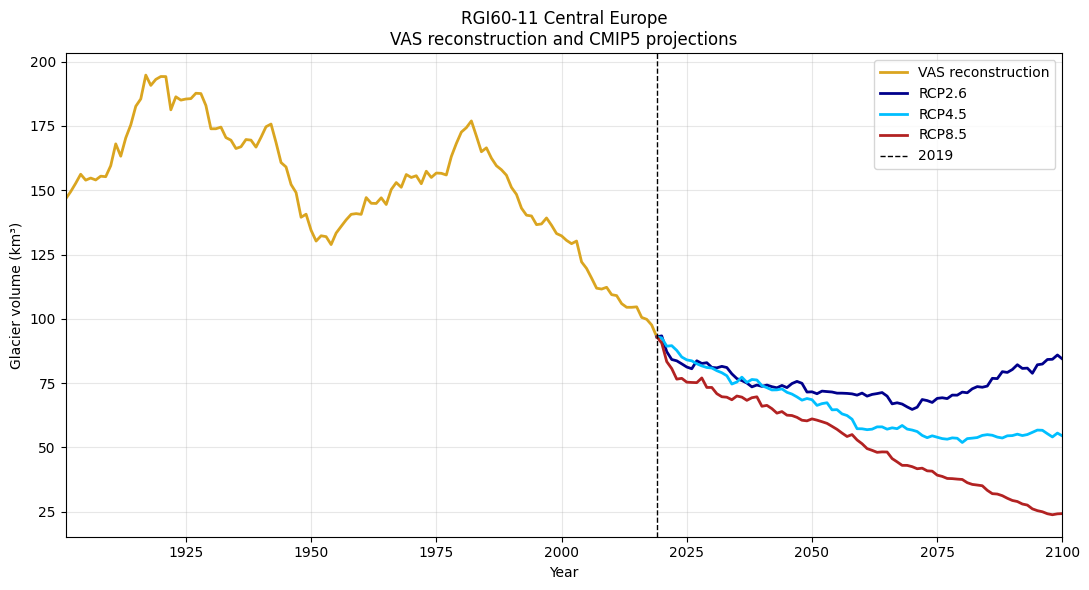

In [42]:
# ============================================================
# 36. PLOT GLACIER VOLUME
# ============================================================

if RUN_FUTURE:

    plt.figure(figsize=(11, 6))

    # Historical reconstruction
    plt.plot(
        historical_plot["year"],
        historical_plot["volume_km3"],
        color="goldenrod",
        linewidth=2,
        label="VAS reconstruction"
    )

    # RCP2.6
    plt.plot(
        future_regional_by_scenario["rcp26"]["year"],
        future_regional_by_scenario["rcp26"]["volume_km3"],
        color="darkblue",
        linewidth=2,
        label="RCP2.6"
    )

    # RCP4.5
    plt.plot(
        future_regional_by_scenario["rcp45"]["year"],
        future_regional_by_scenario["rcp45"]["volume_km3"],
        color="deepskyblue",
        linewidth=2,
        label="RCP4.5"
    )

    # RCP8.5
    plt.plot(
        future_regional_by_scenario["rcp85"]["year"],
        future_regional_by_scenario["rcp85"]["volume_km3"],
        color="firebrick",
        linewidth=2,
        label="RCP8.5"
    )

    # Transition from reconstruction to projection
    plt.axvline(
        2019,
        color="black",
        linestyle="--",
        linewidth=1,
        label="2019"
    )

    plt.xlabel("Year")
    plt.ylabel("Glacier volume (km³)")

    plt.title(
        f"RGI60-{RGI_REGION:02d} Central Europe\n"
        "VAS reconstruction and CMIP5 projections"
    )

    plt.xlim(
        1901,
        2100
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        WORKDIR /
        "volume_1901_2100_all_rcps.png",
        dpi=300
    )

    plt.show()

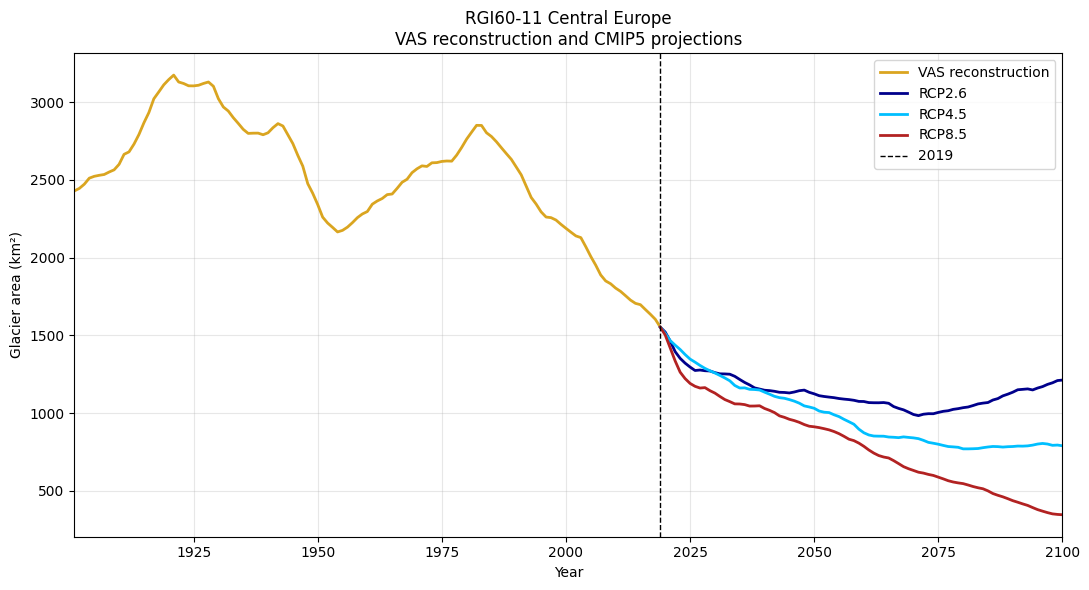

In [43]:
# ============================================================
# 37. PLOT GLACIER AREA
# ============================================================

if RUN_FUTURE:

    plt.figure(figsize=(11, 6))

    # Historical reconstruction
    plt.plot(
        historical_plot["year"],
        historical_plot["area_km2"],
        color="goldenrod",
        linewidth=2,
        label="VAS reconstruction"
    )

    # RCP2.6
    plt.plot(
        future_regional_by_scenario["rcp26"]["year"],
        future_regional_by_scenario["rcp26"]["area_km2"],
        color="darkblue",
        linewidth=2,
        label="RCP2.6"
    )

    # RCP4.5
    plt.plot(
        future_regional_by_scenario["rcp45"]["year"],
        future_regional_by_scenario["rcp45"]["area_km2"],
        color="deepskyblue",
        linewidth=2,
        label="RCP4.5"
    )

    # RCP8.5
    plt.plot(
        future_regional_by_scenario["rcp85"]["year"],
        future_regional_by_scenario["rcp85"]["area_km2"],
        color="firebrick",
        linewidth=2,
        label="RCP8.5"
    )

    # Transition from reconstruction to projection
    plt.axvline(
        2019,
        color="black",
        linestyle="--",
        linewidth=1,
        label="2019"
    )

    plt.xlabel("Year")
    plt.ylabel("Glacier area (km²)")

    plt.title(
        f"RGI60-{RGI_REGION:02d} Central Europe\n"
        "VAS reconstruction and CMIP5 projections"
    )

    plt.xlim(
        1901,
        2100
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        WORKDIR /
        "area_1901_2100_all_rcps.png",
        dpi=300
    )

    plt.show()

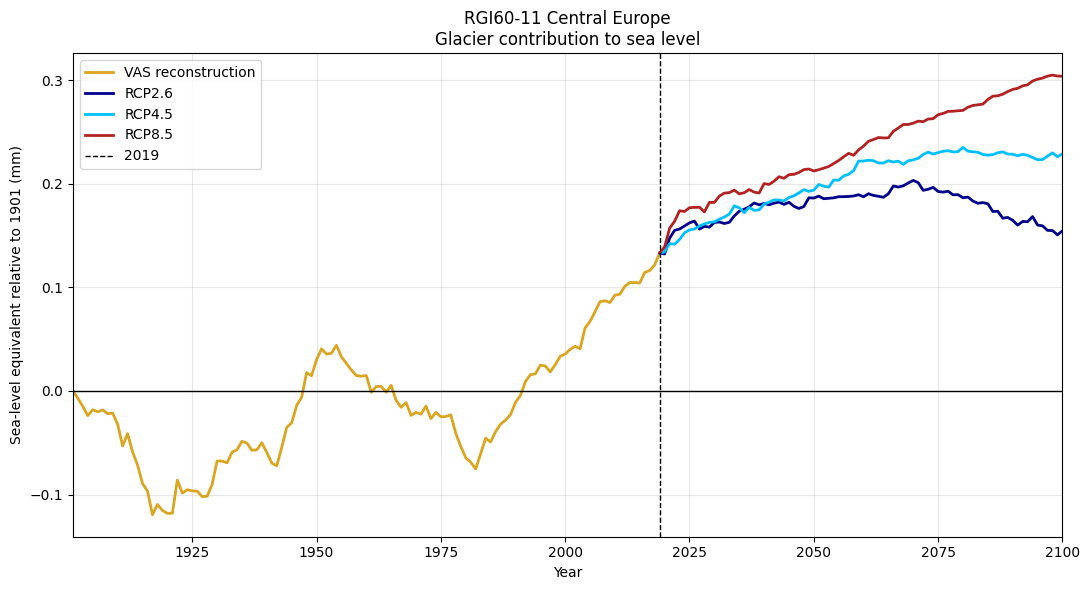

In [44]:
# ============================================================
# 38. PLOT SEA-LEVEL EQUIVALENT
# ============================================================

if RUN_FUTURE:

    plt.figure(figsize=(11, 6))

    # Historical reconstruction
    plt.plot(
        historical_plot["year"],
        historical_plot[
            "sea_level_change_from_1901_mm"
        ],
        color="goldenrod",
        linewidth=2,
        label="VAS reconstruction"
    )

    # RCP2.6
    plt.plot(
        future_sle_by_scenario["rcp26"]["year"],
        future_sle_by_scenario["rcp26"][
            "sea_level_change_from_1901_mm"
        ],
        color="darkblue",
        linewidth=2,
        label="RCP2.6"
    )

    # RCP4.5
    plt.plot(
        future_sle_by_scenario["rcp45"]["year"],
        future_sle_by_scenario["rcp45"][
            "sea_level_change_from_1901_mm"
        ],
        color="deepskyblue",
        linewidth=2,
        label="RCP4.5"
    )

    # RCP8.5
    plt.plot(
        future_sle_by_scenario["rcp85"]["year"],
        future_sle_by_scenario["rcp85"][
            "sea_level_change_from_1901_mm"
        ],
        color="firebrick",
        linewidth=2,
        label="RCP8.5"
    )

    # Transition from reconstruction to projection
    plt.axvline(
        2019,
        color="black",
        linestyle="--",
        linewidth=1,
        label="2019"
    )

    plt.axhline(
        0,
        color="black",
        linewidth=1
    )

    plt.xlabel("Year")
    plt.ylabel(
        "Sea-level equivalent relative to 1901 (mm)"
    )

    plt.title(
        f"RGI60-{RGI_REGION:02d} Central Europe\n"
        "Glacier contribution to sea level"
    )

    plt.xlim(
        1901,
        2100
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        WORKDIR /
        "sea_level_1901_2100_all_rcps.png",
        dpi=300
    )

    plt.show()

In [41]:


# ============================================================
# 40. SAVE COMBINED PROJECTION SUMMARY
# ============================================================

summary_rows = []


for scenario in PROJECTIONS:

    future_plot = (
        future_sle_by_scenario[
            scenario
        ]
    )


    row_2019 = future_plot.loc[
        future_plot["year"] == 2019
    ].iloc[0]


    row_2100 = future_plot.loc[
        future_plot["year"] == 2100
    ].iloc[0]


    summary_rows.append(
        {
            "gcm": GCM,
            "scenario": scenario,
            "scenario_label":
                PROJECTIONS[
                    scenario
                ]["label"],

            "volume_2019_km3":
                row_2019[
                    "volume_km3"
                ],

            "volume_2100_km3":
                row_2100[
                    "volume_km3"
                ],

            "area_2019_km2":
                row_2019[
                    "area_km2"
                ],

            "area_2100_km2":
                row_2100[
                    "area_km2"
                ],

            "sea_level_2100_mm":
                row_2100[
                    "sea_level_change_from_1901_mm"
                ]
        }
    )


projection_summary = pd.DataFrame(
    summary_rows
)


projection_summary.to_csv(
    WORKDIR /
    f"projection_summary_{GCM}.csv",
    index=False
)


print(
    "\nProjection summary:"
)

print(
    projection_summary
)


Projection summary:
     gcm scenario scenario_label  volume_2019_km3  volume_2100_km3  \
0  CCSM4    rcp26         RCP2.6        93.008707        84.371558   
1  CCSM4    rcp45         RCP4.5        93.008707        54.460235   
2  CCSM4    rcp85         RCP8.5        93.008707        24.279776   

   area_2019_km2  area_2100_km2  sea_level_2100_mm  
0    1553.327965    1212.880437           0.154606  
1    1553.327965     790.460969           0.228868  
2    1553.327965     347.394344           0.303799  
